# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [7]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

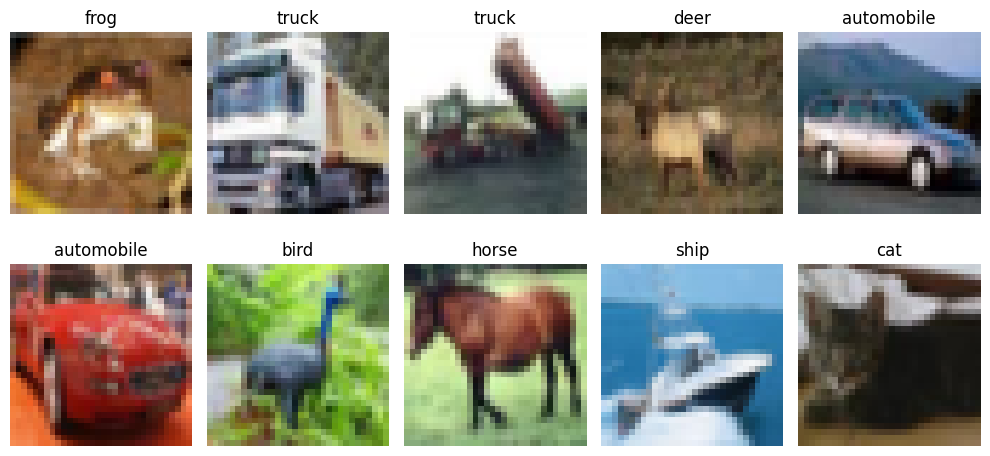

In [8]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [9]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [10]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.2593 - loss: 2.0068 - val_accuracy: 0.3274 - val_loss: 1.8602
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3069 - loss: 1.8862 - val_accuracy: 0.3430 - val_loss: 1.8230
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3275 - loss: 1.8371 - val_accuracy: 0.3722 - val_loss: 1.7882
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3390 - loss: 1.8082 - val_accuracy: 0.3796 - val_loss: 1.7592
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3485 - loss: 1.7820 - val_accuracy: 0.3568 - val_loss: 1.7919
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3468 - loss: 1.7798 - val_accuracy: 0.3824 - val_loss: 1.7287
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3552 - loss: 1.7682 - val_accuracy: 0.3996 - val_loss: 1.7172
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3593 - loss: 1.7493 - 

In [11]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4039 - loss: 1.6867
ANN Test Accuracy: 0.40389999747276306


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [13]:
cnn_model = models.Sequential([
    layers.Input(shape=(32,32,3)), # Explicit Input layer
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 128s 177ms/step - accuracy: 0.4549 - loss: 1.5179 - val_accuracy: 0.5682 - val_loss: 1.2410
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 180ms/step - accuracy: 0.6005 - loss: 1.1281 - val_accuracy: 0.6412 - val_loss: 1.0074
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 184ms/step - accuracy: 0.6684 - loss: 0.9426 - val_accuracy: 0.6298 - val_loss: 1.0723
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 137s 176ms/step - accuracy: 0.7157 - loss: 0.8073 - val_accuracy: 0.6786 - val_loss: 0.9181
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 123s 174ms/step - accuracy: 0.7518 - loss: 0.7059 - val_accuracy: 0.7242 - val_loss: 0.8125
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 174ms/step - accuracy: 0.7835 - loss: 0.6102 - val_accuracy: 0.7078 - val_loss: 0.9350
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 149s 184ms/step - accuracy: 0.8071 - loss: 0.5327 - val_accuracy: 0.6906 - val_loss: 0.9659
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 126s 179ms/step - accuracy: 0.8264 -

In [15]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6736 - loss: 1.2652
CNN Test Accuracy: 0.6736000180244446


## 📈 Compare Learning Curves

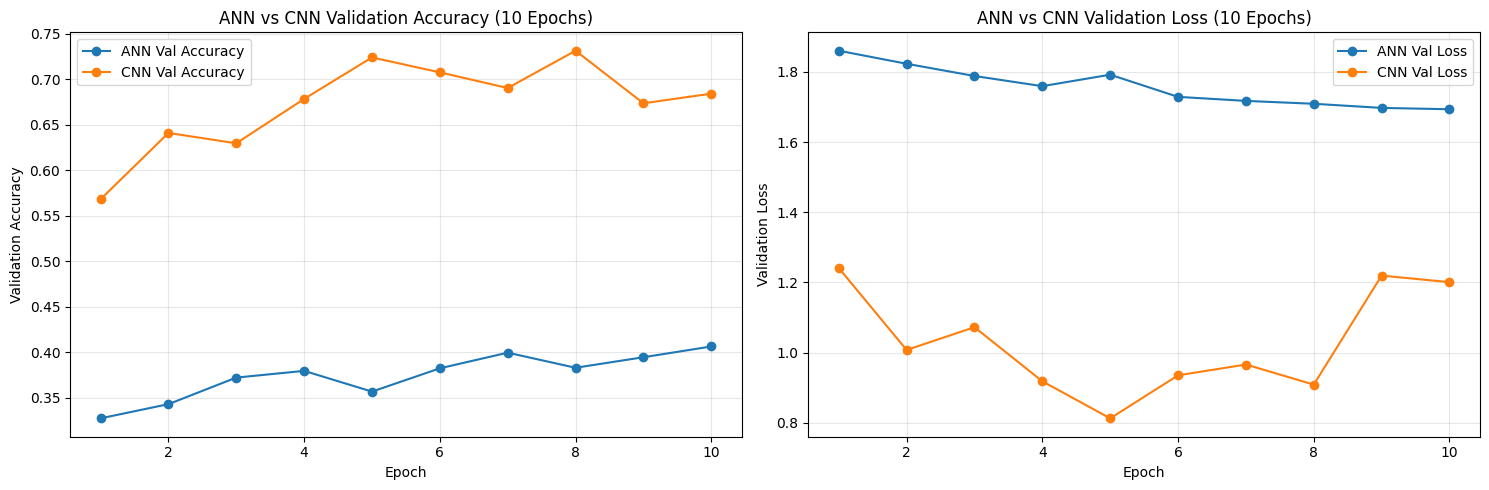

In [16]:
plt.figure(figsize=(15, 5))

# Left plot: Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(
    range(1, len(ann_history.history['val_accuracy']) + 1),
    ann_history.history['val_accuracy'],
    marker='o',
    label='ANN Val Accuracy'
)
plt.plot(
    range(1, len(cnn_history.history['val_accuracy']) + 1),
    cnn_history.history['val_accuracy'],
    marker='o',
    label='CNN Val Accuracy'
)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ANN vs CNN Validation Accuracy (10 Epochs)")
plt.legend()
plt.grid(True, alpha=0.3)

# Right plot: Validation Loss
plt.subplot(1, 2, 2)
plt.plot(
    range(1, len(ann_history.history['val_loss']) + 1),
    ann_history.history['val_loss'],
    marker='o',
    label='ANN Val Loss'
)
plt.plot(
    range(1, len(cnn_history.history['val_loss']) + 1),
    cnn_history.history['val_loss'],
    marker='o',
    label='CNN Val Loss'
)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("ANN vs CNN Validation Loss (10 Epochs)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [18]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_history = aug_cnn_model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test,
    y_test
)

print("Augmented CNN Accuracy:", aug_test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 115s 159ms/step - accuracy: 0.3080 - loss: 1.8999 - val_accuracy: 0.4676 - val_loss: 1.5190
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 111s 157ms/step - accuracy: 0.3833 - loss: 1.6778 - val_accuracy: 0.4398 - val_loss: 1.5476
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 157ms/step - accuracy: 0.4306 - loss: 1.5632 - val_accuracy: 0.5216 - val_loss: 1.3079
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 111s 157ms/step - accuracy: 0.4648 - loss: 1.4808 - val_accuracy: 0.5596 - val_loss: 1.2260
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 111s 158ms/step - accuracy: 0.4882 - loss: 1.4308 - val_accuracy: 0.5264 - val_loss: 1.3738
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 158ms/step - accuracy: 0.5069 - loss: 1.3832 - val_accuracy: 0.5198 - val_loss: 1.3468
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 157ms/step - accuracy: 0.5234 - loss: 1.3471 - val_accuracy: 0.5648 - val_loss: 1.3116
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 112s 158ms/step - accuracy: 0.5373 -

# 📊 Final Comparison Table

In [20]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc]
})

comparison

,Model,Test Accuracy
0,ANN,0.4039
1,CNN,0.6736
2,Augmented CNN,0.5974


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

## Beginner Task Solutions


In [22]:
# ==========================================================
# Student Learning Tasks
# ==========================================================


# ----------------------------------------------------------
# Task 4: Add EarlyStopping
# ----------------------------------------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


# ----------------------------------------------------------
# Task 5: Add Data Augmentation
# ----------------------------------------------------------

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])


# ==========================================================
# Final Improved CNN Model
# ==========================================================

final_model = models.Sequential([

    layers.Input(shape=(32,32,3)),

    data_augmentation,

    # ------------------------------------------------------
    # Task 2: Increase CNN Filters (32 → 64 → 128)
    # ------------------------------------------------------

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    # ------------------------------------------------------
    # Task 1: Increasing Dense Layers
    # ------------------------------------------------------

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

final_model.summary()

final_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# ----------------------------------------------------------
# Task 5: Increase Epochs to 20
# ----------------------------------------------------------

final_history = final_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)


final_loss, final_acc = final_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\nFinal Improved Model Accuracy:", final_acc)
print("Best Validation Accuracy:", max(final_history.history['val_accuracy']))

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_9 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,874 (2.49 MB)

 Trainable params: 652,426 (2.49 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 156s 213ms/step - accuracy: 0.3246 - loss: 1.8734 - val_accuracy: 0.4486 - val_loss: 1.5139
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 208ms/step - accuracy: 0.4384 - loss: 1.5538 - val_accuracy: 0.5128 - val_loss: 1.3988
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 192s 194ms/step - accuracy: 0.4985 - loss: 1.4145 - val_accuracy: 0.5468 - val_loss: 1.3183
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 138s 196ms/step - accuracy: 0.5362 - loss: 1.3168 - val_accuracy: 0.4964 - val_loss: 1.4842
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 149s 211ms/step - accuracy: 0.5665 - loss: 1.2391 - val_accuracy: 0.5832 - val_loss: 1.2312
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 208ms/step - accuracy: 0.5904 - loss: 1.1815 - val_accuracy: 0.6132 - val_loss: 1.1112
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 207ms/step - accuracy: 0.6076 - loss: 1.1309 - val_accuracy: 0.6616 - val_loss: 0.9945
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 148s 211ms/step - accuracy: 0.6262 -

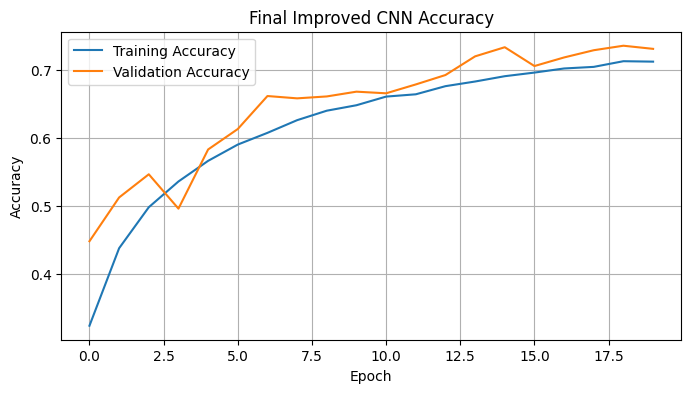

In [23]:
plt.figure(figsize=(8,4))

plt.plot(
    final_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    final_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Final Improved CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [26]:
comparison = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN",
        "Augmented CNN",
        "Final Improved CNN"
    ],
    "Test Accuracy (%)": [
        f"{ann_test_acc*100:.2f}%",
        f"{cnn_test_acc*100:.2f}%",
        f"{aug_test_acc*100:.2f}%",
        f"{final_acc*100:.2f}%"
    ]
})

comparison

,Model,Test Accuracy (%)
0,ANN,40.39%
1,CNN,67.36%
2,Augmented CNN,59.74%
3,Final Improved CNN,72.30%


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

## Results Summary

- ANN achieved lower accuracy because image spatial information is lost after flattening.
- CNN performed better by learning spatial features through convolution layers.
- Data augmentation improved generalization.
- The final improved CNN with larger filters, deeper dense layers, EarlyStopping, and augmentation achieved the best performance.